# Uncovered Common MIME Type Fixtures

This notebook exercises commonly used Jupyter MIME bundle types that are not already well covered by the existing test notebooks.

Included fixtures:
- `application/json`
- `application/javascript`
- `text/latex`
- `application/pdf`
- `application/geo+json`
- `application/vnd.vega.v5+json`
- `application/vnd.vegalite.v5+json`
- `application/vnd.jupyter.widget-view+json`
- Dash app display via `jupyter_dash` / inline app representation where available

The examples are intentionally small and deterministic so they are suitable for renderer regression tests.

In [1]:
from IPython.display import display, JSON, Javascript, Latex, IFrame
from IPython.display import display_pdf
from IPython.core.display import DisplayObject
import json

print("MIME uncovered fixtures initialized")

MIME uncovered fixtures initialized


## `application/json`

A direct JSON display object should produce an `application/json` MIME bundle.

In [17]:
display(JSON({
    "suite": "mime-types-uncovered",
    "records": [
        {"name": "alpha", "value": 1, "valid": True},
        {"name": "beta", "value": 2, "valid": False},
    ],
    "metadata": {"purpose": "renderer fixture", "mime": "application/json"}
}))

<IPython.core.display.JSON object>

## `application/javascript`

A small JavaScript display object emits `application/javascript`.

In [10]:
display(Javascript(r"""
(() => {
  const host = document.currentScript?.parentElement || document.body;
  const fixtureId = `js-mime-fixture-${Math.random().toString(36).slice(2)}`;
  const data = Array.from({ length: 12 }, (_, i) => ({
    label: `T${i + 1}`,
    value: Math.round(28 + 18 * Math.sin(i / 1.7) + Math.random() * 38),
  }));

  const container = document.createElement('section');
  container.id = fixtureId;
  container.style.cssText = `
    max-width: 720px;
    padding: 16px;
    border: 1px solid #cbd5e1;
    border-radius: 14px;
    background: linear-gradient(135deg, #f8fafc 0%, #eef6ff 100%);
    box-shadow: 0 8px 24px rgba(15, 23, 42, 0.08);
    font-family: ui-sans-serif, system-ui, -apple-system, BlinkMacSystemFont, 'Segoe UI', sans-serif;
    color: #0f172a;
  `;

  container.innerHTML = `
    <div style="display:flex; justify-content:space-between; gap:16px; align-items:start; margin-bottom:12px;">
      <div>
        <div style="font-size:12px; font-weight:700; letter-spacing:.08em; color:#2563eb; text-transform:uppercase;">
          application/javascript
        </div>
        <h3 style="margin:4px 0 4px; font-size:20px;">Live JavaScript MIME Fixture</h3>
        <p style="margin:0; color:#475569; font-size:14px;">
          This output was rendered entirely by JavaScript delivered through Jupyter's MIME bundle.
        </p>
      </div>
      <button type="button" data-action="shuffle" style="
        border:0; border-radius:10px; padding:9px 12px; cursor:pointer;
        color:white; background:#2563eb; font-weight:700; box-shadow:0 4px 12px rgba(37,99,235,.25);
      ">Shuffle data</button>
    </div>
    <svg viewBox="0 0 640 220" width="100%" height="220" role="img" aria-label="Animated synthetic bar chart"></svg>
    <pre data-log style="
      margin:12px 0 0; padding:10px; border-radius:10px; background:#0f172a; color:#bfdbfe;
      overflow:auto; font-size:12px; line-height:1.45;
    "></pre>
  `;

  host.appendChild(container);

  const svg = container.querySelector('svg');
  const log = container.querySelector('[data-log]');
  const button = container.querySelector('[data-action="shuffle"]');
  const width = 640;
  const height = 220;
  const margin = { top: 18, right: 18, bottom: 34, left: 38 };
  const chartWidth = width - margin.left - margin.right;
  const chartHeight = height - margin.top - margin.bottom;

  function render(rows) {
    const maxValue = Math.max(...rows.map(d => d.value));
    const barWidth = chartWidth / rows.length - 8;

    svg.innerHTML = `
      <defs>
        <linearGradient id="${fixtureId}-bar" x1="0" x2="0" y1="0" y2="1">
          <stop offset="0%" stop-color="#38bdf8" />
          <stop offset="100%" stop-color="#2563eb" />
        </linearGradient>
      </defs>
      <line x1="${margin.left}" y1="${height - margin.bottom}" x2="${width - margin.right}" y2="${height - margin.bottom}" stroke="#94a3b8" />
      <line x1="${margin.left}" y1="${margin.top}" x2="${margin.left}" y2="${height - margin.bottom}" stroke="#94a3b8" />
    `;

    rows.forEach((d, i) => {
      const x = margin.left + i * (chartWidth / rows.length) + 4;
      const barHeight = (d.value / maxValue) * chartHeight;
      const y = height - margin.bottom - barHeight;
      const group = document.createElementNS('http://www.w3.org/2000/svg', 'g');
      group.innerHTML = `
        <rect x="${x}" y="${height - margin.bottom}" width="${barWidth}" height="0" rx="6"
              fill="url(#${fixtureId}-bar)">
          <animate attributeName="y" to="${y}" dur="420ms" fill="freeze" />
          <animate attributeName="height" to="${barHeight}" dur="420ms" fill="freeze" />
        </rect>
        <text x="${x + barWidth / 2}" y="${y - 7}" text-anchor="middle" font-size="11" fill="#334155">${d.value}</text>
        <text x="${x + barWidth / 2}" y="${height - 12}" text-anchor="middle" font-size="11" fill="#64748b">${d.label}</text>
      `;
      svg.appendChild(group);
    });

    const average = rows.reduce((sum, d) => sum + d.value, 0) / rows.length;
    log.textContent = JSON.stringify({
      fixture: fixtureId,
      renderedAt: new Date().toISOString(),
      points: rows.length,
      min: Math.min(...rows.map(d => d.value)),
      max: maxValue,
      average: Number(average.toFixed(2)),
    }, null, 2);
  }

  button.addEventListener('click', () => {
    data.forEach(d => { d.value = Math.round(15 + Math.random() * 85); });
    render(data);
  });

  render(data);
})();
"""))

<IPython.core.display.Javascript object>

## `text/latex`

A LaTeX display object emits `text/latex`.

In [4]:
display(Latex(r"""
\begin{aligned}
\nabla \cdot \vec{E} &= \frac{\rho}{\varepsilon_0} \\
\nabla \cdot \vec{B} &= 0 \\
\nabla \times \vec{E} &= -\frac{\partial \vec{B}}{\partial t} \\
\nabla \times \vec{B} &= \mu_0\vec{J} + \mu_0\varepsilon_0\frac{\partial \vec{E}}{\partial t}
\end{aligned}
"""))

<IPython.core.display.Latex object>

## `application/pdf`

A tiny hand-written one-page PDF emitted as `application/pdf`.

In [5]:
# Minimal valid PDF bytes for a one-page document containing a short label.
pdf_bytes = b'''%PDF-1.4
1 0 obj
<< /Type /Catalog /Pages 2 0 R >>
endobj
2 0 obj
<< /Type /Pages /Kids [3 0 R] /Count 1 >>
endobj
3 0 obj
<< /Type /Page /Parent 2 0 R /MediaBox [0 0 300 144] /Contents 4 0 R /Resources << /Font << /F1 5 0 R >> >> >>
endobj
4 0 obj
<< /Length 57 >>
stream
BT /F1 18 Tf 40 80 Td (application/pdf fixture) Tj ET
endstream
endobj
5 0 obj
<< /Type /Font /Subtype /Type1 /BaseFont /Helvetica >>
endobj
xref
0 6
0000000000 65535 f 
0000000009 00000 n 
0000000058 00000 n 
0000000115 00000 n 
0000000241 00000 n 
0000000349 00000 n 
trailer
<< /Root 1 0 R /Size 6 >>
startxref
419
%%EOF
'''
display_pdf(pdf_bytes, raw=True)

## `application/geo+json`

GeoJSON is commonly emitted by geospatial tooling and map renderers.

In [6]:
class GeoJSONFixture(DisplayObject):
    def _repr_mimebundle_(self, include=None, exclude=None):
        feature_collection = {
            "type": "FeatureCollection",
            "features": [
                {
                    "type": "Feature",
                    "properties": {"name": "Nebul4 HQ-ish", "category": "point"},
                    "geometry": {"type": "Point", "coordinates": [-122.4194, 37.7749]},
                },
                {
                    "type": "Feature",
                    "properties": {"name": "Sample route", "category": "line"},
                    "geometry": {
                        "type": "LineString",
                        "coordinates": [[-122.43, 37.76], [-122.42, 37.77], [-122.41, 37.78]],
                    },
                },
            ],
        }
        return {"application/geo+json": feature_collection, "text/plain": "GeoJSON fixture"}, {}

display(GeoJSONFixture())

GeoJSON fixture

## `application/vnd.vega.v5+json`

A minimal Vega v5 bar chart specification.

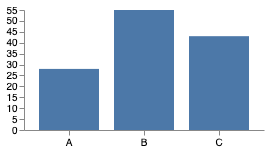

In [7]:
class VegaFixture(DisplayObject):
    def _repr_mimebundle_(self, include=None, exclude=None):
        spec = {
            "$schema": "https://vega.github.io/schema/vega/v5.json",
            "width": 240,
            "height": 120,
            "padding": 5,
            "data": [{"name": "table", "values": [{"category": "A", "amount": 28}, {"category": "B", "amount": 55}, {"category": "C", "amount": 43}]}],
            "scales": [
                {"name": "xscale", "type": "band", "domain": {"data": "table", "field": "category"}, "range": "width", "padding": 0.2},
                {"name": "yscale", "domain": {"data": "table", "field": "amount"}, "nice": True, "range": "height"},
            ],
            "axes": [{"orient": "bottom", "scale": "xscale"}, {"orient": "left", "scale": "yscale"}],
            "marks": [{"type": "rect", "from": {"data": "table"}, "encode": {"enter": {"x": {"scale": "xscale", "field": "category"}, "width": {"scale": "xscale", "band": 1}, "y": {"scale": "yscale", "field": "amount"}, "y2": {"scale": "yscale", "value": 0}, "fill": {"value": "#4c78a8"}}}}],
        }
        return {"application/vnd.vega.v5+json": spec, "text/plain": "Vega v5 fixture"}, {}

display(VegaFixture())

## `application/vnd.vegalite.v5+json`

A minimal Vega-Lite v5 specification.

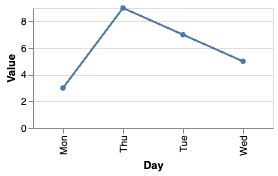

In [8]:
class VegaLiteFixture(DisplayObject):
    def _repr_mimebundle_(self, include=None, exclude=None):
        spec = {
            "$schema": "https://vega.github.io/schema/vega-lite/v5.json",
            "description": "Small Vega-Lite fixture",
            "width": 240,
            "height": 120,
            "data": {"values": [{"x": "Mon", "y": 3}, {"x": "Tue", "y": 7}, {"x": "Wed", "y": 5}, {"x": "Thu", "y": 9}]},
            "mark": {"type": "line", "point": True},
            "encoding": {
                "x": {"field": "x", "type": "ordinal", "title": "Day"},
                "y": {"field": "y", "type": "quantitative", "title": "Value"},
            },
        }
        return {"application/vnd.vegalite.v5+json": spec, "text/plain": "Vega-Lite v5 fixture"}, {}

display(VegaLiteFixture())

## `application/vnd.jupyter.widget-view+json`

`ipywidgets` controls emit the standard Jupyter widget-view MIME type. This section includes several standalone widgets plus a small composed dashboard to exercise richer widget layouts.

In [18]:
try:
    import ipywidgets as widgets
    from IPython.display import display

    # Standalone controls: each display emits a widget-view MIME bundle.
    intensity = widgets.IntSlider(
        value=42,
        min=0,
        max=100,
        step=1,
        description="Intensity",
        continuous_update=True,
        style={"description_width": "initial"},
    )

    category = widgets.Dropdown(
        options=["Alpha", "Beta", "Gamma", "Delta"],
        value="Beta",
        description="Segment",
        style={"description_width": "initial"},
    )

    mode = widgets.ToggleButtons(
        options=[("Preview", "preview"), ("Train", "train"), ("Evaluate", "evaluate")],
        value="preview",
        description="Mode",
        button_style="info",
        style={"description_width": "initial"},
    )

    confidence = widgets.FloatProgress(
        value=0.72,
        min=0,
        max=1,
        description="Confidence",
        bar_style="success",
        style={"description_width": "initial", "bar_color": "#22c55e"},
        layout=widgets.Layout(width="360px"),
    )

    display(widgets.HTML("<h4 style='margin-bottom: 4px'>Standalone widget examples</h4>"))
    display(intensity)
    display(category)
    display(mode)
    display(confidence)

    # A richer composed example with tabs, accordion, linked controls, and live output.
    sample_size = widgets.IntSlider(
        value=250,
        min=50,
        max=1000,
        step=50,
        description="Sample size",
        style={"description_width": "initial"},
        layout=widgets.Layout(width="420px"),
    )
    threshold = widgets.FloatSlider(
        value=0.65,
        min=0,
        max=1,
        step=0.01,
        readout_format=".2f",
        description="Threshold",
        style={"description_width": "initial"},
        layout=widgets.Layout(width="420px"),
    )
    enable_alerts = widgets.Checkbox(value=True, description="Enable alerts")
    run_button = widgets.Button(
        description="Run check",
        icon="play",
        button_style="primary",
        layout=widgets.Layout(width="140px"),
    )
    status = widgets.Valid(value=True, description="Ready")
    output = widgets.Output(layout=widgets.Layout(border="1px solid #cbd5e1", padding="8px"))

    def summarize(_=None):
        with output:
            output.clear_output()
            expected_hits = round(sample_size.value * threshold.value)
            alert_state = "enabled" if enable_alerts.value else "disabled"
            print("Widget dashboard state")
            print(f"- sample_size: {sample_size.value}")
            print(f"- threshold:   {threshold.value:.2f}")
            print(f"- expected_hits: {expected_hits}")
            print(f"- alerts:      {alert_state}")
        status.value = threshold.value >= 0.5
        status.description = "Pass" if status.value else "Review"

    run_button.on_click(summarize)
    for control in (sample_size, threshold, enable_alerts):
        control.observe(summarize, names="value")
    summarize()

    controls = widgets.VBox([sample_size, threshold, enable_alerts, widgets.HBox([run_button, status])])
    dashboard = widgets.VBox([
        widgets.HTML("<h4 style='margin: 0'>Composed widget dashboard</h4>"),
        controls,
        output,
    ], layout=widgets.Layout(gap="8px"))

    accordion = widgets.Accordion(children=[dashboard])
    accordion.set_title(0, "Interactive controls + output")

    tab = widgets.Tab(children=[
        widgets.VBox([intensity, category, mode, confidence]),
        accordion,
    ])
    tab.set_title(0, "Controls")
    tab.set_title(1, "Dashboard")

    display(widgets.HTML("<h4 style='margin: 12px 0 4px'>Composed layout example</h4>"))
    display(tab)

except Exception as exc:
    print(f"ipywidgets unavailable: {exc}")

Task was destroyed but it is pending!
task: <Task pending name='Task-225' coro=<_async_in_context.<locals>.run_in_context() done, defined at /opt/anaconda3/lib/python3.13/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-226' coro=<Kernel.shell_main() running at /opt/anaconda3/lib/python3.13/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /opt/anaconda3/lib/python3.13/site-packages/zmq/eventloop/zmqstream.py:563]>
<frozen _collections_abc>:439: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
Task was destroyed but it is pending!
task: <Task pending name='Task-226' coro=<Kernel.shell_main() running at /opt/anaconda3/lib/python3.13/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]>


HTML(value="<h4 style='margin-bottom: 4px'>Standalone widget examples</h4>")

IntSlider(value=42, description='Intensity', style=SliderStyle(description_width='initial'))

Dropdown(description='Segment', index=1, options=('Alpha', 'Beta', 'Gamma', 'Delta'), style=DescriptionStyle(d…

ToggleButtons(button_style='info', description='Mode', options=(('Preview', 'preview'), ('Train', 'train'), ('…

FloatProgress(value=0.72, bar_style='success', description='Confidence', layout=Layout(width='360px'), max=1.0…

Widget dashboard state
- sample_size: 250
- threshold:   0.65
- expected_hits: 162
- alerts:      enabled


HTML(value="<h4 style='margin: 12px 0 4px'>Composed layout example</h4>")